# 대선자료 시각화

In [161]:
# 모듈 불러오기
import pandas as pd

In [162]:
# Data 불러오기
election = pd.read_csv("../Data/election_2022.csv")
election.head()

,광역시도,시군구,선거인수,투표수,이재명,윤석열,심상정
0,서울특별시,종로구,129968,100629,46130,49172,3115
1,서울특별시,중구,111448,84998,38244,42906,2310
2,서울특별시,용산구,199077,152068,60063,85047,4374
3,서울특별시,성동구,252087,197240,84411,103880,5365
4,서울특별시,광진구,303582,235471,109922,113733,7072


In [163]:
# 기본 통계량 확인하기 : 갯수, 평균, 표준편차, 1~4사분위수, 최대값 등등
election.describe()

,선거인수,투표수,이재명,윤석열,심상정
count,248.00000,248.00000,248.00000,248.00000,248.00000
mean,176570.54032,136147.83871,64479.10484,65566.29032,3215.53226
std,141049.73198,108569.70632,56875.86443,56766.36576,2893.69580
min,8141.00000,6653.00000,1590.00000,2052.00000,109.00000
25%,47671.50000,39215.75000,17363.00000,18223.00000,709.00000
50%,154353.50000,114654.00000,48797.00000,50341.00000,2617.50000
75%,265099.25000,204189.25000,99830.75000,101949.75000,5041.00000
max,703896.00000,542027.00000,285227.00000,275155.00000,13249.00000


In [164]:
# 컬럼명 확인하기
election.columns

Index(['광역시도', '시군구', '선거인수', '투표수', '이재명', '윤석열', '심상정'], dtype='object')

In [165]:
# dimension 확인하기 
election.shape

(248, 7)

In [166]:
# 컬럼별 자료형 확인하기
election.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   광역시도    248 non-null    object
 1   시군구     248 non-null    object
 2   선거인수    248 non-null    int64 
 3   투표수     248 non-null    int64 
 4   이재명     248 non-null    int64 
 5   윤석열     248 non-null    int64 
 6   심상정     248 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 13.7+ KB


In [167]:
# 전체 컬럼에 대해 NaN 확인
election.isnull().any()

광역시도    False
시군구     False
선거인수    False
투표수     False
이재명     False
윤석열     False
심상정     False
dtype: bool

In [168]:
election['electionSum'] = election.iloc[:,4:].sum(axis="columns")
election.head()

,광역시도,시군구,선거인수,투표수,이재명,윤석열,심상정,electionSum
0,서울특별시,종로구,129968,100629,46130,49172,3115,98417
1,서울특별시,중구,111448,84998,38244,42906,2310,83460
2,서울특별시,용산구,199077,152068,60063,85047,4374,149484
3,서울특별시,성동구,252087,197240,84411,103880,5365,193656
4,서울특별시,광진구,303582,235471,109922,113733,7072,230727


In [169]:
# election['electionRatio']

election['electionRatio'] = round(election.loc[:,'electionSum'] / election.loc[:,'투표수'] * 100, 2)
election.head()

,광역시도,시군구,선거인수,투표수,이재명,윤석열,심상정,electionSum,electionRatio
0,서울특별시,종로구,129968,100629,46130,49172,3115,98417,97.80000
1,서울특별시,중구,111448,84998,38244,42906,2310,83460,98.19000
2,서울특별시,용산구,199077,152068,60063,85047,4374,149484,98.30000
3,서울특별시,성동구,252087,197240,84411,103880,5365,193656,98.18000
4,서울특별시,광진구,303582,235471,109922,113733,7072,230727,97.99000


In [170]:
# csv로 저장하기

# election.to_csv("../Data/election_2022_20220704.csv", index=False)

---
### 광역시별 투표율을 Pie Chart로 표현하기

In [171]:
# 광역시도별 전국 투표율

# elec_sum = election.pivot_table('투표수', index='광역시도', aggfunc=sum)
# elec_sum.head()

election_origin = election.groupby('광역시도').sum()
election_origin.sort_values(by='투표수', ascending=False, inplace=True)
election_origin

,선거인수,투표수,이재명,윤석열,심상정,electionSum,electionRatio
광역시도,,,,,,,
경기도,11106036,8518854,4297931,3859666,201113,8358710,4018.96000
서울특별시,8346647,6501831,2944981,3255747,180324,6381052,2453.06000
부산광역시,2921510,2200224,831896,1270072,47541,2149509,1562.69000
경상남도,2809907,2146882,794130,1237346,52591,2084067,2132.21000
인천광역시,2519225,1883504,913320,878560,51852,1843732,976.71000
경상북도,2273028,1774284,418371,1278922,33123,1730416,2339.40000
대구광역시,2046714,1611512,345045,1199888,31131,1576064,781.81000
충청남도,1796474,1324660,589991,670283,31789,1292063,1560.70000
전라남도,1581278,1282168,1094872,145549,16279,1256700,2152.66000


In [172]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [173]:
# data = elec_sum_order['투표수']
# categories = list(elec_sum_order.index)

In [203]:
# 한글 폰트 문제 해결 
# matplotlib은 한글 폰트를 지원하지 않음
# os정보
import platform

# font_manager : 폰트 관리 모듈
# rc : 폰트 변경 모듈
from matplotlib import font_manager, rc
# unicode 설정
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic') # os가 macos
elif platform.system() == 'Windows':
    path = 'c:/Windows/Fonts/malgun.ttf' # os가 windows
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print("Unknown System")

In [175]:
# 파이차트
plt.style.use('default')

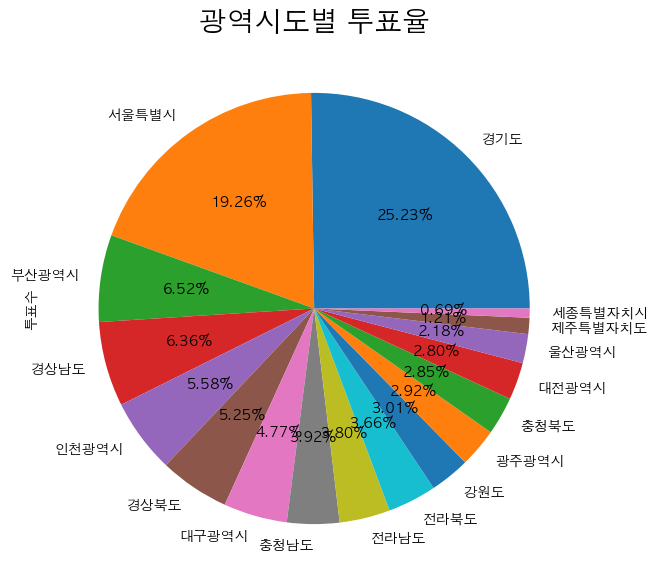

In [187]:

# plt.rcParams['figure.figsize'] = (12,12)
# plt.rcParams['font.size'] = 20

election_origin['투표수'].plot(
    kind='pie',
    figsize = (10,7),
    autopct = '%.2f%%',
)

plt.title('광역시도별 투표율', size=20)
plt.show()

In [177]:
# 윤석열 후보의 공역시도별 득표율
election_origin.head()


,선거인수,투표수,이재명,윤석열,심상정,electionSum,electionRatio
광역시도,,,,,,,
경기도,11106036,8518854,4297931,3859666,201113,8358710,4018.96000
서울특별시,8346647,6501831,2944981,3255747,180324,6381052,2453.06000
부산광역시,2921510,2200224,831896,1270072,47541,2149509,1562.69000
경상남도,2809907,2146882,794130,1237346,52591,2084067,2132.21000
인천광역시,2519225,1883504,913320,878560,51852,1843732,976.71000


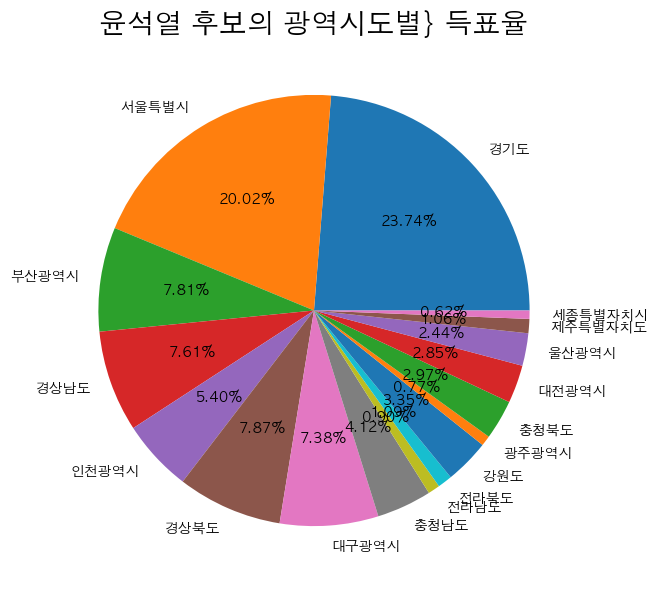

In [188]:

election_origin['윤석열'].plot(
    kind='pie',
    figsize = (10, 7),
    autopct = '%.2f%%'
)

plt.title('윤석열 후보의 광역시도별} 득표율', size=20)
plt.ylabel('')
plt.show()

In [179]:
elec_seoul = election.loc[election['광역시도'] == '서울특별시',['시군구','윤석열']]
elec_seoul.sort_values(by='윤석열', ascending=False, inplace=True)
elec_seoul.set_index('시군구', inplace=True)
elec_seoul

,윤석열
시군구,
송파구,255166
강남구,235897
강서구,181510
서초구,179472
노원구,163340
강동구,160593
관악구,151944
양천구,149780
은평구,140666


In [180]:
elec_seoul_top5 = elec_seoul.iloc[:5,:]
elec_seoul_top5


,윤석열
시군구,
송파구,255166
강남구,235897
강서구,181510
서초구,179472
노원구,163340


In [181]:
elec_seoul_top5.loc['기타',] = elec_seoul.iloc[5:,].sum()
elec_seoul_top5

,윤석열
시군구,
송파구,255166.00000
강남구,235897.00000
강서구,181510.00000
서초구,179472.00000
노원구,163340.00000
기타,2240362.00000


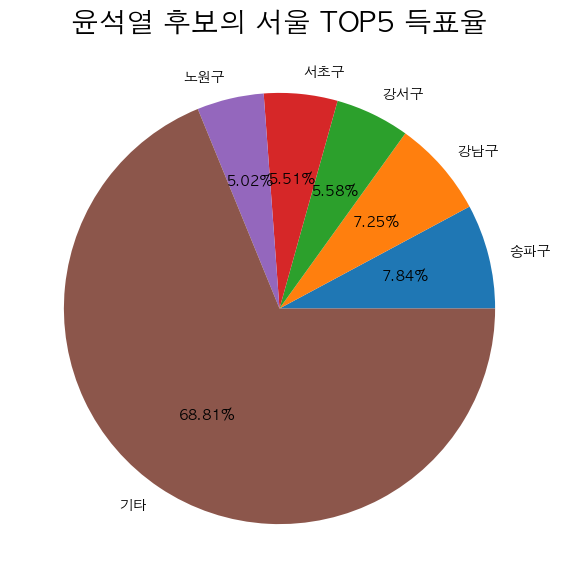

In [189]:
elec_seoul_top5['윤석열'].plot(
    kind='pie',
    figsize = (10, 7),
    autopct = '%.2f%%',
)

plt.title('윤석열 후보의 서울 TOP5 득표율', size=20)
plt.ylabel('')
plt.show()

# 대선주자 출생지별 득표율 분
- 윤석열 후보의 출생지는 서울 특별시 성북구

In [191]:
elec_sb = election.loc[election['시군구'] == '성북구']
elec_sb

,광역시도,시군구,선거인수,투표수,이재명,윤석열,심상정,electionSum,electionRatio
7,서울특별시,성북구,375880,292187,142702,135044,8952,286698,98.12000


In [194]:
elec_sb['기타'] = elec_sb['투표수'] - (election.iloc[:,4:7].sum(axis="columns"))
elec_sb
elec_sb_data = \
    pd.Series([int(elec_sb['윤석열']), int(elec_sb['이재명']), int(elec_sb['심상정'])]).\
        append(elec_sb['투표수'] - elec_sb['electionSum']).reset_index(drop=True)
elec_sb_data

0    135044
1    142702
2      8952
3      5489
dtype: int64

In [195]:
elec_sb = elec_sb.iloc[:,[5,4,6,9]]
elec_sb

,윤석열,이재명,심상정,기타
7,135044,142702,8952,5489.00000


In [193]:
elec_sb.T

,7
광역시도,서울특별시
시군구,성북구
선거인수,375880
투표수,292187
이재명,142702
윤석열,135044
심상정,8952
electionSum,286698
electionRatio,98.12000


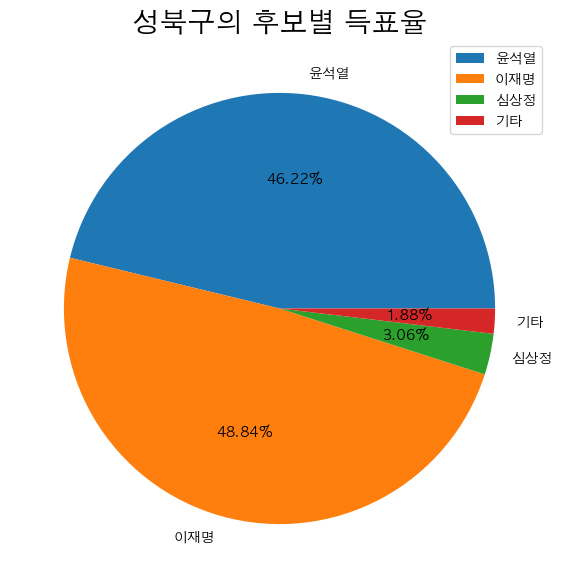

In [196]:
elec_sb.T.plot(
    kind='pie',
    figsize = (10, 7),
    autopct = '%.2f%%',
    subplots=True,

)

plt.title('성북구의 후보별 득표율', size=20)
plt.ylabel('')
plt.show()

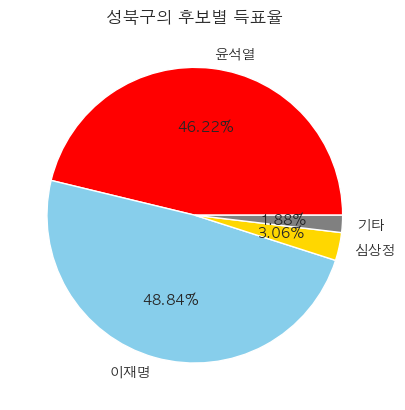

In [ ]:
# 파이차트로 그리기
plt.pie(
    elec_sb_data,
    labels=['윤석열', '이재명', '심상정', '기타'],
    autopct = '%.2f%%',
    colors=['red','#87CEEB','gold','gray']
)

plt.title('성북구의 후보별 득표율')
plt.show()

---
###  투표수가 가장 많은 4지역(광역시도)의 각 후보별 득표수를 막대그래프로 표현하기

In [ ]:
# 한글 폰트 문제 해결 
# matplotlib은 한글 폰트를 지원하지 않음
# os정보
import platform

# font_manager : 폰트 관리 모듈
# rc : 폰트 변경 모듈
from matplotlib import font_manager, rc
# unicode 설정
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic') # os가 macos
elif platform.system() == 'Windows':
    path = 'c:/Windows/Fonts/malgun.ttf' # os가 windows
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print("Unknown System")

In [199]:
election_origin.sort_values(by='투표수', ascending=False, inplace=True)
election_origin_top4 = election_origin.iloc[:4,[3,2,4]]

In [200]:
import seaborn as sns
sns.set_style('whitegrid')

In [205]:
election_origin_top4 = election_origin_top4 / 1000
election_origin_top4

,윤석열,이재명,심상정
광역시도,,,
경기도,3859.66600,4297.93100,201.11300
서울특별시,3255.74700,2944.98100,180.32400
부산광역시,1270.07200,831.89600,47.54100
경상남도,1237.34600,794.13000,52.59100


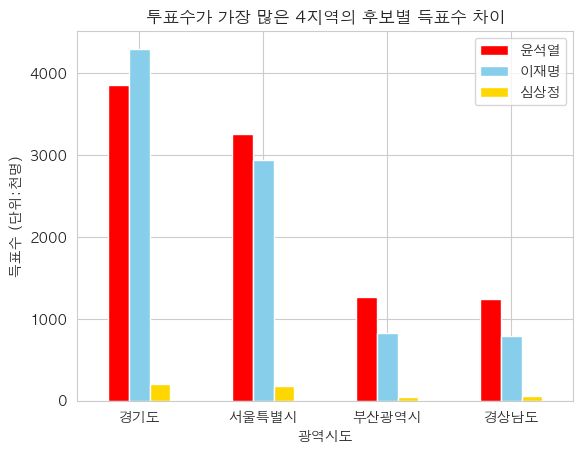

In [206]:
# plt.style.use('seaborn-whitegrid')
# plt.rcParams['font.family'] = 'Malgun Gothic'

election_origin_top4.plot(
    kind='bar',
    color = ['red','#87CEEB','gold'],
    
)


plt.yticks(rotation=360)
plt.xticks(rotation=360)
plt.ylabel('득표수 (단위:천명)')
plt.title('투표수가 가장 많은 4지역의 후보별 득표수 차이')

# current_values = plt.gca().get_yticks()
# plt.gca().set_yticklabels(['{:.0f}'.format(x) for x in current_values])

plt.show()

---
# 투표수가 높은 5군데 시군구의 후보별 득표수

In [208]:
election.sort_values(by='투표수', ascending=False, inplace=True)

In [230]:
elec_vote_top5 = election.iloc[:5,[0,1,5,4,6]]
elec_vote_top5

,광역시도,시군구,윤석열,이재명,심상정
100,경기도,화성시,236055,283324,12955
85,경기도,부천시,224331,285227,13249
98,경기도,남양주시,203075,239179,10089
23,서울특별시,송파구,255166,180490,10652
15,서울특별시,강서구,181510,190000,11100


In [231]:
elec_vote_top5['시군'] = elec_vote_top5['광역시도']+ " " +elec_vote_top5['시군구']
elec_vote_top5

,광역시도,시군구,윤석열,이재명,심상정,시군
100,경기도,화성시,236055,283324,12955,경기도 화성시
85,경기도,부천시,224331,285227,13249,경기도 부천시
98,경기도,남양주시,203075,239179,10089,경기도 남양주시
23,서울특별시,송파구,255166,180490,10652,서울특별시 송파구
15,서울특별시,강서구,181510,190000,11100,서울특별시 강서구


In [232]:
elec_vote_top5.set_index('시군', inplace=True)

In [233]:
elec_vote_top5 = elec_vote_top5.iloc[:,2:]

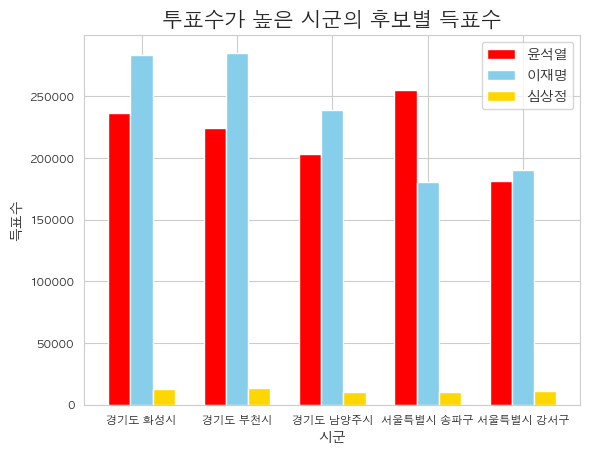

In [254]:
elec_vote_top5.plot(
    kind = 'bar',
    color = ['red','#87CEEB','gold'],
    fontsize = 8,
    rot = 0,
    width = 0.7
)

# plt.yticks(rotation=0)
# plt.xticks(rotation=0)
plt.ylabel('득표수')
plt.title('투표수가 높은 시군의 후보별 득표수', size=15)
# plt.savefig('../Data/투표수가 높은 시군구의 후보별 득표수.png')

plt.show()